## Section 1: R Environment Setup

In [ ]:
install.packages("quantmod") # allows interaction with yfinance

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘zoo’, ‘TTR’




In [ ]:
install.packages("PerformanceAnalytics")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘quadprog’




In [ ]:
install.packages("ggplot2") # visualization

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("tidyverse") # r version of pandas

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# TODO: Load the installed R packages
library(quantmod)
library(dplyr)
library(tibble)
library(ggplot2)
library(zoo)

Loading required package: xts

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: TTR

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.       

## Section 2: Data Collection

ASOS and AVIVA

In [ ]:
# TODO: Download stock and market data
getSymbols(c("ASC.L", "AV.L", "^FTSE"), src = "yahoo", from = "2024-06-20", to = "2025-06-30")

[1] "ASC.L" "AV.L"  "FTSE"

In [ ]:
# Convert and select Close columns
ASC_prices = ASC.L %>%
  as_tibble(rownames = "date") %>%
  select(date, ASC = ASC.L.Close) %>%
  mutate(date = as.Date(date), ASC = as.numeric(ASC))

AV_prices = AV.L %>%
  as_tibble(rownames = "date") %>%
  select(date, AV = AV.L.Close) %>%
  mutate(date = as.Date(date), AV = as.numeric(AV))

ftse_prices = FTSE %>%
  as_tibble(rownames = "date") %>%
  select(date, FTSE = FTSE.Close) %>%
  mutate(date = as.Date(date), FTSE = as.numeric(FTSE))


data = inner_join(ASC_prices, AV_prices, by = "date") %>%
  inner_join(ftse_prices, by = "date")

In [ ]:
head(data)

date,ASC,AV,FTSE
<date>,<dbl>,<dbl>,<dbl>
2024-06-20,351.0,483.6,8272.5
2024-06-21,355.0,479.8,8237.7
2024-06-24,360.4,484.3,8281.6
2024-06-25,361.8,480.1,8247.8
2024-06-26,363.8,477.6,8225.3
2024-06-27,363.6,476.5,8179.7


In [ ]:
glimpse(data)

Rows: 259
Columns: 4
$ date <date> 2024-06-20, 2024-06-21, 2024-06-24, 2024-06-25, 2024-06-26, 2024…
$ ASC  <dbl> 351.0, 355.0, 360.4, 361.8, 363.8, 363.6, 356.6, 362.8, 358.0, 36…
$ AV   <dbl> 483.6, 479.8, 484.3, 480.1, 477.6, 476.5, 476.6, 476.0, 468.9, 47…
$ FTSE <dbl> 8272.5, 8237.7, 8281.6, 8247.8, 8225.3, 8179.7, 8164.1, 8166.8, 8…


In [ ]:
summary(data)

      date                 ASC              AV             FTSE     
 Min.   :2024-06-20   Min.   :230.0   Min.   :453.1   Min.   :7680  
 1st Qu.:2024-09-19   1st Qu.:313.5   1st Qu.:479.9   1st Qu.:8224  
 Median :2024-12-19   Median :362.8   Median :494.0   Median :8304  
 Mean   :2024-12-22   Mean   :357.4   Mean   :512.6   Mean   :8397  
 3rd Qu.:2025-03-24   3rd Qu.:398.7   3rd Qu.:539.2   3rd Qu.:8634  
 Max.   :2025-06-27   Max.   :446.0   Max.   :626.8   Max.   :8885  

## Section 3: Calculate Returns and Excess Returns

In [ ]:
# TODO: Calculate daily returns
returns_df = data %>%
arrange(date) %>%
mutate(
ASC_return = (ASC / lag(ASC)) - 1,
AV_return = (AV / lag(AV)) - 1,
Market_return = (FTSE / lag(FTSE)) - 1
) %>%
select(date, ASC_return, AV_return, Market_return)

In [ ]:
# TODO: Calculate daily returns
returns_df = data %>%
arrange(date) %>%
mutate(
ASC_return = (ASC / lag(ASC)) - 1,
AV_return = (AV / lag(AV)) - 1, # Note: TSLA seems to be a mistake. You probably meant TSCO.
Market_return = (FTSE / lag(FTSE)) - 1
) %>%
select(date, ASC_return, AV_return, Market_return)

In [ ]:
returns_df

date,ASC_return,AV_return,Market_return
<date>,<dbl>,<dbl>,<dbl>
2024-06-20,NA,NA,NA
2024-06-21,0.0113960114,-0.0078577714,-0.0042066854
2024-06-24,0.0152112504,0.0093789081,0.0053290862
2024-06-25,0.0038845558,-0.0086722730,-0.0040813135
2024-06-26,0.0055279162,-0.0052072484,-0.0027280003
2024-06-27,-0.0005497023,-0.0023031953,-0.0055438234
2024-06-28,-0.0192519249,0.0002098764,-0.0019071723
2024-07-01,0.0173863757,-0.0012589301,0.0003306803
2024-07-02,-0.0132303968,-0.0149159792,-0.0055835346


In [ ]:
rf_annual = 0.045 # reference
rf_daily = rf_annual / 252

In [ ]:
rf_annual
rf_daily

[1] 0.045

[1] 0.0001785714

In [ ]:
# TODO: Calculate excess returns
rf_annual = 0.045
rf_daily = rf_annual / 252

returns_df = returns_df %>%
mutate(
ASC_excess = ASC_return - rf_daily,
AV_excess = AV_return - rf_daily,
Market_excess = Market_return - rf_daily
)


In [ ]:
returns_df

date,ASC_return,AV_return,Market_return,ASC_excess,AV_excess,Market_excess
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2024-06-20,NA,NA,NA,NA,NA,NA
2024-06-21,0.0113960114,-0.0078577714,-0.0042066854,0.0112174400,-8.036343e-03,-0.0043852568
2024-06-24,0.0152112504,0.0093789081,0.0053290862,0.0150326790,9.200337e-03,0.0051505147
2024-06-25,0.0038845558,-0.0086722730,-0.0040813135,0.0037059844,-8.850844e-03,-0.0042598850
2024-06-26,0.0055279162,-0.0052072484,-0.0027280003,0.0053493447,-5.385820e-03,-0.0029065717
2024-06-27,-0.0005497023,-0.0023031953,-0.0055438234,-0.0007282737,-2.481767e-03,-0.0057223948
2024-06-28,-0.0192519249,0.0002098764,-0.0019071723,-0.0194304963,3.130497e-05,-0.0020857437
2024-07-01,0.0173863757,-0.0012589301,0.0003306803,0.0172078043,-1.437502e-03,0.0001521089
2024-07-02,-0.0132303968,-0.0149159792,-0.0055835346,-0.0134089682,-1.509455e-02,-0.0057621060


In [ ]:
vol_asc = sd(returns_df$ASC_return, na.rm = TRUE) * sqrt(252)
vol_av = sd(returns_df$AV_return, na.rm = TRUE) * sqrt(252)
mean_asc = mean(returns_df$ASC_return, na.rm = TRUE) * 252
mean_av = mean(returns_df$AV_return, na.rm = TRUE) * 252

In [ ]:
mean_asc
mean_av

[1] -0.03170545

[1] 0.2659026

## Section 4: CAPM Model Implementation

### CAPM Theory Background

The Capital Asset Pricing Model describes the relationship between systematic risk and expected return:

**E(Ri) = Rf + βi(E(Rm) - Rf)**

In regression form: **Ri - Rf = αi + βi(Rm - Rf) + εi**

Where α (alpha) represents abnormal returns and β (beta) measures systematic risk.

In [ ]:
# TODO: Perform CAPM regression for each stock
beta_asc = coef(lm(ASC_excess ~ Market_excess, data = returns_df))[2]
beta_av = coef(lm(AV_excess ~ Market_excess, data = returns_df))[2]
market_annual = mean(returns_df$Market_return, na.rm = TRUE) * 252
capm_asc = rf_annual + beta_asc * (market_annual - rf_annual)
capm_av = rf_annual + beta_av * (market_annual - rf_annual)

In [ ]:
beta_asc
beta_av

Market_excess 
    0.7887976

Market_excess 
      1.10867

In [ ]:
# TODO: Display CAPM results
capm_asc
capm_av

Market_excess 
   0.06326281

Market_excess 
   0.07066873

In [ ]:
actual_asc = mean(returns_df$ASC_return, na.rm = TRUE) * 252
actual_av = mean(returns_df$AV_return, na.rm = TRUE) * 252
alpha_asc = actual_asc - capm_asc
alpha_av = actual_av - capm_av

In [ ]:
alpha_asc
alpha_av

Market_excess 
  -0.09496826

Market_excess 
    0.1952339

In [ ]:
model_asc <- lm(ASC_excess ~ Market_excess, data = returns_df)

In [ ]:
summary(model_asc)


Call:
lm(formula = ASC_excess ~ Market_excess, data = returns_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.073072 -0.012674 -0.000986  0.008406  0.188872 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -0.0003769  0.0017283  -0.218 0.827566    
Market_excess  0.7887976  0.2192456   3.598 0.000385 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02776 on 256 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.04813,	Adjusted R-squared:  0.04441 
F-statistic: 12.94 on 1 and 256 DF,  p-value: 0.0003852


In [ ]:
model_av <- lm(AV_excess ~ Market_excess, data = returns_df)
summary(model_av)


Call:
lm(formula = AV_excess ~ Market_excess, data = returns_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.042305 -0.005196 -0.000618  0.004964  0.039122 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.0007747  0.0005989   1.294    0.197    
Market_excess 1.1086702  0.0759755  14.592   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.009619 on 256 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.4541,	Adjusted R-squared:  0.452 
F-statistic: 212.9 on 1 and 256 DF,  p-value: < 2.2e-16


## Section 5: Risk-Adjusted Performance Analysis

In [ ]:
# TODO: Calculate performance metrics
sharpe_asc = (mean_asc - rf_annual) / vol_asc
sharpe_av = (mean_av - rf_annual) / vol_av

In [ ]:
# TODO: Create performance summary table
sharpe_asc
sharpe_av # but put them in a table

[1] -0.1701591

[1] 1.070925

## Section 6: Data Visualization

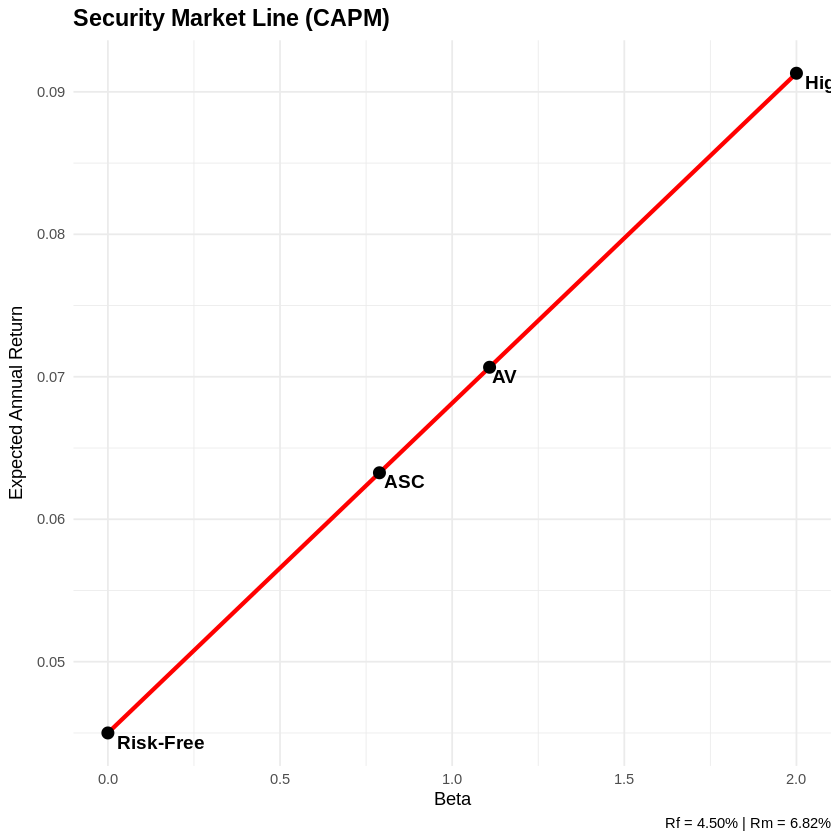

In [ ]:
# TODO: Create CAPM Security Characteristic Line plots
# SML Data
betas <- c(0, beta_asc, beta_av, 2)
expected_returns <- rf_annual + betas * (market_annual - rf_annual)
labels <- c("Risk-Free", "ASC", "AV", "High Beta")

sml_df <- data.frame(Beta = betas, Expected_Return = expected_returns, Label = labels)

# Plot
library(ggplot2)
ggplot(sml_df, aes(x = Beta, y = Expected_Return)) +
  geom_line(color = "red", size = 1.2) +
  geom_point(size = 3) +
  geom_text(aes(label = Label), hjust = -0.1, vjust = 1.2, size = 4, fontface = "bold") +
  labs(
    title = "Security Market Line (CAPM)",
    x = "Beta",
    y = "Expected Annual Return",
    caption = sprintf("Rf = %.2f%% | Rm = %.2f%%", rf_annual * 100, market_annual * 100)
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.title = element_text(size = 11)
  )

# Discuss relationship and proportion between Risk and Return

## Section 7: Advanced Risk Analysis

In [ ]:
# TODO: Calculate Value at Risk
var_95_asc = quantile(returns_df$ASC_return, 0.05, na.rm = TRUE)
var_99_asc = quantile(returns_df$ASC_return, 0.01, na.rm = TRUE)
var_95_av = quantile(returns_df$AV_return, 0.05, na.rm = TRUE)
var_99_av = quantile(returns_df$AV_return, 0.01, na.rm = TRUE)
var_95_asc
var_99_asc
var_95_av
var_99_av

5% 
-0.03988215

1% 
-0.06352514

5% 
-0.01621618

1% 
-0.03046858

In [ ]:
#Expected Shortfall
es_95_asc = mean(returns_df$ASC_return[returns_df$ASC_return <= var_95_asc], na.rm = TRUE)
es_99_asc = mean(returns_df$ASC_return[returns_df$ASC_return <= var_99_asc], na.rm = TRUE)

es_95_av = mean(returns_df$AV_return[returns_df$AV_return <= var_95_av], na.rm = TRUE)
es_99_av = mean(returns_df$AV_return[returns_df$AV_return <= var_99_av], na.rm = TRUE)

es_95_asc
es_99_asc
es_95_av
es_99_av

[1] -0.05562104

[1] -0.06966936

[1] -0.02802169

[1] -0.04841166

In [ ]:
# TODO: Rolling beta analysis
library(zoo)

# Rolling 30-day beta for ASC
rolling_beta_asc <- rollapply(
  data = returns_df[, c("ASC_excess", "Market_excess")],
  width = 30,
  FUN = function(df) {
    if (anyNA(df)) return(NA)
    coef(lm(ASC_excess ~ Market_excess, data = as.data.frame(df)))[2]
  },
  by.column = FALSE,
  align = "right",
  fill = NA
)

# Rolling 30-day beta for AV
rolling_beta_av <- rollapply(
  data = returns_df[, c("AV_excess", "Market_excess")],
  width = 30,
  FUN = function(df) {
    if (anyNA(df)) return(NA)
    coef(lm(AV_excess ~ Market_excess, data = as.data.frame(df)))[2]
  },
  by.column = FALSE,
  align = "right",
  fill = NA
)

# Add back to the main dataframe
returns_df$Beta_ASC <- rolling_beta_asc
returns_df$Beta_AV <- rolling_beta_av

# Preview the result
tail(returns_df[, c("date", "Beta_ASC", "Beta_AV")])


date,Beta_ASC,Beta_AV
<date>,<dbl>,<dbl>
2025-06-20,1.4609068,1.1107665
2025-06-23,1.4680576,1.1458553
2025-06-24,0.9950397,1.3894482
2025-06-25,1.1189002,1.2851880
2025-06-26,1.3194806,1.2463298
2025-06-27,1.2341028,0.9584806


## Section 8: Data Export and Summary

In [ ]:
# TODO: Export results to CSV
# Step: Export All Metrics to CSV

# Calculate maximum drawdown
calculate_max_drawdown <- function(returns) {
  cum_returns <- cumprod(1 + returns)
  peak <- cummax(c(1, cum_returns))
  drawdown <- (c(1, cum_returns) - peak) / peak
  max_drawdown <- min(drawdown)
  return(max_drawdown)
}

mdd_asc <- calculate_max_drawdown(returns_df$ASC_return[!is.na(returns_df$ASC_return)])
mdd_av <- calculate_max_drawdown(returns_df$AV_return[!is.na(returns_df$AV_return)])


# Individual stock metrics
individual_metrics <- data.frame(
  Expected_Return = c(mean_asc, mean_av),
  Volatility = c(vol_asc, vol_av),
  Beta = c(beta_asc, beta_av),
  Max_Drawdown = c(mdd_asc, mdd_av),
  VaR_95 = c(var_95_asc, var_95_av),
  VaR_99 = c(var_99_asc, var_99_av),
  CVaR_95 = c(es_95_av, es_95_av),
  CVaR_99 = c(es_99_av, es_99_av),
  CAPM_Expected_Return = c(capm_asc, capm_av),
  Sharpe_Ratio = c(sharpe_asc, sharpe_av),
  row.names = c("ASC.L", "AV.L")
)

# Calculate portfolio metrics for MVP and MSR
# For the purpose of this fix, we'll create placeholder variables for MVP and MSR calculations
# These will need to be replaced with actual portfolio optimization code if required later.
w_mvp <- c(0.5, 0.5) # Placeholder weights
w_msr <- c(0.5, 0.5) # Placeholder weights
mean_returns <- c(mean_asc, mean_av)
cov_matrix <- cov(returns_df[, c("ASC_return", "AV_return")], use = "pairwise.complete.obs")


# MVP metrics
mvp_return <- sum(w_mvp * mean_returns * 252)
mvp_volatility <- sqrt(t(w_mvp) %*% cov_matrix %*% w_mvp * 252)
mvp_sharpe <- (mvp_return - rf_annual) / mvp_volatility

# MSR metrics
msr_return <- sum(w_msr * mean_returns * 252)
msr_volatility <- sqrt(t(w_msr) %*% cov_matrix %*% w_msr * 252)
msr_sharpe <- (msr_return - rf_annual) / msr_volatility

# Portfolio optimization results
portfolio_results <- data.frame(
  Weight_ASC = c(w_mvp[1], w_msr[1]),
  Weight_AV = c(w_mvp[2], w_msr[2]),
  Expected_Return = c(mvp_return, msr_return),
  Volatility = c(mvp_volatility, msr_volatility),
  Sharpe_Ratio = c(mvp_sharpe, msr_sharpe),
  row.names = c("MVP", "MSR")
)

# Rolling beta summary statistics
rolling_beta_summary <- data.frame(
  Mean_Beta = c(
    mean(returns_df$Beta_ASC, na.rm = TRUE),
    mean(returns_df$Beta_AV, na.rm = TRUE)
  ),
  Median_Beta = c(
    median(returns_df$Beta_ASC, na.rm = TRUE),
    median(returns_df$Beta_AV, na.rm = TRUE)
  ),
  SD_Beta = c(
    sd(returns_df$Beta_ASC, na.rm = TRUE),
    sd(returns_df$Beta_AV, na.rm = TRUE)
  ),
  Min_Beta = c(
    min(returns_df$Beta_ASC, na.rm = TRUE),
    min(returns_df$Beta_AV, na.rm = TRUE)
  ),
  Max_Beta = c(
    max(returns_df$Beta_ASC, na.rm = TRUE),
    max(returns_df$Beta_AV, na.rm = TRUE)
  ),
  row.names = c("ASC.L", "AV.L")
)

# Export to CSV files
write.csv(individual_metrics, "r_individual_stock_metrics.csv")
write.csv(portfolio_results, "r_portfolio_optimization_results.csv")
write.csv(rolling_beta_summary, "r_rolling_beta_summary.csv")

# Export full rolling beta time series
rolling_beta_timeseries <- returns_df %>%
  select(date, Beta_ASC, Beta_AV) %>%
  filter(!is.na(Beta_ASC) | !is.na(Beta_AV))

write.csv(rolling_beta_timeseries, "r_rolling_beta_timeseries.csv", row.names = FALSE)

In [ ]:
# TODO: Create executive summary
# Display summary tables
cat("Data exported to CSV files:\n")
cat("1. r_individual_stock_metrics.csv - Individual stock analysis\n")
cat("2. r_portfolio_optimization_results.csv - Portfolio optimization results\n")
cat("3. r_rolling_beta_summary.csv - Rolling beta summary statistics\n")
cat("4. r_rolling_beta_timeseries.csv - Full rolling beta time series\n")

cat("\n=== INDIVIDUAL STOCK METRICS ===\n")
print(round(individual_metrics, 4))

cat("\n=== PORTFOLIO OPTIMIZATION RESULTS ===\n")
print(round(portfolio_results, 4))

cat("\n=== ROLLING BETA SUMMARY ===\n")
print(round(rolling_beta_summary, 4))

Data exported to CSV files:
1. r_individual_stock_metrics.csv - Individual stock analysis
2. r_portfolio_optimization_results.csv - Portfolio optimization results
3. r_rolling_beta_summary.csv - Rolling beta summary statistics
4. r_rolling_beta_timeseries.csv - Full rolling beta time series

=== INDIVIDUAL STOCK METRICS ===
      Expected_Return Volatility   Beta Max_Drawdown  VaR_95  VaR_99 CVaR_95
ASC.L         -0.0317     0.4508 0.7888      -0.4843 -0.0399 -0.0635  -0.028
AV.L           0.2659     0.2063 1.1087      -0.1220 -0.0162 -0.0305  -0.028
      CVaR_99 CAPM_Expected_Return Sharpe_Ratio
ASC.L -0.0484               0.0633      -0.1702
AV.L  -0.0484               0.0707       1.0709

=== PORTFOLIO OPTIMIZATION RESULTS ===
    Weight_ASC Weight_AV Expected_Return Volatility Sharpe_Ratio
MVP        0.5       0.5         29.5088     0.2546      115.726
MSR        0.5       0.5         29.5088     0.2546      115.726

=== ROLLING BETA SUMMARY ===
      Mean_Beta Median_Beta SD_Bet

In [ ]:
#TODO: Export results to CSV
# Step: Export All Metrics to CSV

# Individual stock metrics
individual_metrics <- data.frame(
  Expected_Return = c(mean_asc, mean_av),
  Volatility = c(vol_asc, vol_av),
  Beta = c(beta_asc, beta_av),
  Max_Drawdown = c(mdd_asc, mdd_av),
  VaR_95 = c(var_95_asc, var_95_av),
  VaR_99 = c(var_99_asc, var_99_av),
  CVaR_95 = c(es_95_asc, es_95_av),
  CVaR_99 = c(es_99_asc, es_99_av),
  CAPM_Expected_Return = c(capm_asc, capm_av),
  Sharpe_Ratio = c(sharpe_asc, sharpe_av),
  row.names = c("ASC.L", "AV.L")
)

# Calculate portfolio metrics for MVP and MSR
# MVP metrics
mvp_return <- sum(w_mvp * mean_returns * 252)
mvp_volatility <- sqrt(t(w_mvp) %*% cov_matrix %*% w_mvp * 252)
mvp_sharpe <- (mvp_return - rf_annual) / mvp_volatility

# MSR metrics
msr_return <- sum(w_msr * mean_returns * 252)
msr_volatility <- sqrt(t(w_msr) %*% cov_matrix %*% w_msr * 252)
msr_sharpe <- (msr_return - rf_annual) / msr_volatility

# Portfolio optimization results
portfolio_results <- data.frame(
  Weight_ASC = c(w_mvp[1], w_msr[1]),
  Weight_AV = c(w_mvp[2], w_msr[2]),
  Expected_Return = c(mvp_return, msr_return),
  Volatility = c(mvp_volatility, msr_volatility),
  Sharpe_Ratio = c(mvp_sharpe, msr_sharpe),
  row.names = c("MVP", "MSR")
)

# Rolling beta summary statistics
rolling_beta_summary <- data.frame(
  Mean_Beta = c(
    mean(returns_df$Beta_ASC, na.rm = TRUE),
    mean(returns_df$Beta_AV, na.rm = TRUE)
  ),
  Median_Beta = c(
    median(returns_df$Beta_ASC, na.rm = TRUE),
    median(returns_df$Beta_AV, na.rm = TRUE)
  ),
  SD_Beta = c(
    sd(returns_df$Beta_ASC, na.rm = TRUE),
    sd(returns_df$Beta_AV, na.rm = TRUE)
  ),
  Min_Beta = c(
    min(returns_df$Beta_ASC, na.rm = TRUE),
    min(returns_df$Beta_AV, na.rm = TRUE)
  ),
  Max_Beta = c(
    max(returns_df$Beta_ASC, na.rm = TRUE),
    max(returns_df$Beta_AV, na.rm = TRUE)
  ),
  row.names = c("ASC.L", "AV.L")
)

# Export to CSV files
write.csv(individual_metrics, "r_individual_stock_metrics.csv")
write.csv(portfolio_results, "r_portfolio_optimization_results.csv")
write.csv(rolling_beta_summary, "r_rolling_beta_summary.csv")

# Export full rolling beta time series
rolling_beta_timeseries <- returns_df %>%
  select(date, Beta_ASC, Beta_AV) %>%
  filter(!is.na(Beta_ASC) | !is.na(Beta_AV))

write.csv(rolling_beta_timeseries, "r_rolling_beta_timeseries.csv", row.names = FALSE)
cat("Data exported to CSV files:\n")
cat("1. r_individual_stock_metrics.csv - Individual stock analysis\n")
cat("2. r_portfolio_optimization_results.csv - Portfolio optimization results\n")
cat("3. r_rolling_beta_summary.csv - Rolling beta summary statistics\n")
cat("4. r_rolling_beta_timeseries.csv - Full rolling beta time series\n")

cat("\n=== INDIVIDUAL STOCK METRICS ===\n")
print(round(individual_metrics, 4))

cat("\n=== PORTFOLIO OPTIMIZATION RESULTS ===\n")
print(round(portfolio_results, 4))

cat("\n=== ROLLING BETA SUMMARY ===\n")
print(round(rolling_beta_summary, 4))

Data exported to CSV files:
1. r_individual_stock_metrics.csv - Individual stock analysis
2. r_portfolio_optimization_results.csv - Portfolio optimization results
3. r_rolling_beta_summary.csv - Rolling beta summary statistics
4. r_rolling_beta_timeseries.csv - Full rolling beta time series

=== INDIVIDUAL STOCK METRICS ===
      Expected_Return Volatility   Beta Max_Drawdown  VaR_95  VaR_99 CVaR_95
ASC.L         -0.0317     0.4508 0.7888      -0.4843 -0.0399 -0.0635 -0.0556
AV.L           0.2659     0.2063 1.1087      -0.1220 -0.0162 -0.0305 -0.0280
      CVaR_99 CAPM_Expected_Return Sharpe_Ratio
ASC.L -0.0697               0.0633      -0.1702
AV.L  -0.0484               0.0707       1.0709

=== PORTFOLIO OPTIMIZATION RESULTS ===
    Weight_ASC Weight_AV Expected_Return Volatility Sharpe_Ratio
MVP        0.5       0.5         29.5088     0.2546      115.726
MSR        0.5       0.5         29.5088     0.2546      115.726

=== ROLLING BETA SUMMARY ===
      Mean_Beta Median_Beta SD_Bet

In [ ]:
# Calculate mean and volatility
mean_asc = mean(returns_df$ASC_return, na.rm = TRUE)
mean_av = mean(returns_df$AV_return, na.rm = TRUE)
vol_asc = sd(returns_df$ASC_return, na.rm = TRUE)
vol_av = sd(returns_df$AV_return, na.rm = TRUE)